# 07 — ArrowSpace Basins × Epiplexity: Separating Trivial from Useful Structure

**Question.** A low-energy basin is not automatically a *useful* basin. Some basins are smooth
because they contain meaningful, compressible structure. Others are smooth because they are
trivial: locally regular, easy to predict, and mechanically uninteresting.

This notebook demonstrates the three-way basin typology proposed in
[Part 3](https://www.tuned.org.uk/posts/022_arrowspace_basins_and_epiplexity_part_3/)
of the ArrowSpace for Latent Spaces series, using:

1. **ArrowSpace** spectral features ($\lambda\tau$ scores, graph Laplacian $L_F$) for locality / coherence.
2. The **`epiplexity`** library (`EpiplexityEngine` + `ArrowSpaceModelAdapter`) for the MDL two-part
   code: structural bits $S_T$ (learnable novelty) + entropy bits $H_T$ (residual surprise).
3. A **closed-form reservoir epiplexity estimator** (Zhang & Levin 2026, eq 9) implemented as a
   `TTimeProbabilisticModel` subclass, giving per-regime $S^\phi$ and $H_T$.

### The three regimes

| Regime | ArrowSpace profile | Epiplexity profile | Interpretation |
|---|---|---|---|
| **Trivial basin** | Smooth (low roughness) | Low $S_T$ | Regular but mechanically uninteresting |
| **Useful basin** | Locally coherent | High $S_T$ | Structured and learnable; strong intervention target |
| **Noisy boundary** | Rough (high roughness) | Low $S_T$, high $H_T$ | Surprising but not learnable |

### References

- Zhang & Levin, *Intelligence from Learnable Novelty*, arXiv:2607.18433 (2026)
- Finzi et al., [From Entropy to Epiplexity](https://arxiv.org/abs/2601.03220) (2026)
- ArrowSpace: [From Embedding Geometry to Spectral Search](https://arxiv.org/abs/2606.21535)
- `epiplexity` library: `pip install epiplexity`
- `arrowspace` library: `pip install arrowspace`


## 0 · Imports and configuration

In [1]:
import math
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

from arrowspace import ArrowSpaceBuilder
from epiplexity.engine import EpiplexityEngine
from epiplexity.algorithms.arrowspace import ArrowSpaceModelAdapter
from epiplexity.model import TTimeProbabilisticModel

SEED = 3407
rng = np.random.default_rng(SEED)

plt.rcParams.update({
    "figure.dpi": 140, "font.size": 11, "axes.grid": True,
    "grid.alpha": 0.3, "figure.constrained_layout.use": True,
})

OUT = Path("output__07")
OUT.mkdir(exist_ok=True)
print("Output:", OUT.resolve())


Output: /Users/tuned-silicon/code/arrowspace-analysis/notebooks/output__07


---
## 1 · Synthetic regimes: trivial, useful, noisy

Three well-separated regimes in $\mathbb{R}^{32}$, each with 80 points:

- **Trivial** — a 1-D smooth manifold (ellipse) lifted to 32-D via two random basis vectors.
  Smooth and coherent, but only rank-2: few learnable directions.
- **Useful** — an 8-D smooth manifold built from sinusoidal functions of 8 latent coordinates
  projected through a random 8×32 basis. Smooth AND rich: many learnable directions.
- **Noisy** — i.i.d. isotropic Gaussian noise. Rough, no learnable structure.

The regimes are translated far apart so that kNN neighbourhoods are regime-pure.


In [2]:
D = 32
N_PER = 80

# Trivial: rank-2 smooth ellipse
t = np.linspace(0, 2 * np.pi, N_PER)
rng.shuffle(t)
b1 = rng.standard_normal(D); b1 /= np.linalg.norm(b1)
b2 = rng.standard_normal(D); b2 /= np.linalg.norm(b2)
cA = np.zeros(D); cA[0] = 12.0
A = cA + (np.cos(t)[:, None] * b1 + np.sin(t)[:, None] * b2) * 2.0 + 0.01 * rng.standard_normal((N_PER, D))

# Useful: rank-8 smooth manifold
lat = rng.standard_normal((N_PER, 8))
basis8 = rng.standard_normal((8, D))
basis8 /= np.linalg.norm(basis8, axis=1, keepdims=True)
phi = np.stack([np.sin(lat[:, j] * (j + 1)) for j in range(8)], axis=1)
cB = np.zeros(D); cB[1] = 12.0
B = cB + phi @ basis8 * (2.0 / np.sqrt(8)) + 0.01 * rng.standard_normal((N_PER, D))

# Noisy: i.i.d. isotropic
cC = np.zeros(D); cC[2] = 12.0
C = cC + rng.standard_normal((N_PER, D)) * 1.5

items = np.vstack([A, B, C]).astype(np.float64)
labels = np.array(["trivial"] * N_PER + ["useful"] * N_PER + ["noisy"] * N_PER)
REGIMES = ["trivial", "useful", "noisy"]
COLORS  = {"trivial": "#a6e3a1", "useful": "#89b4fa", "noisy": "#f38ba8"}

N = len(items)
print(f"Dataset: {N} items x {D} dims, 3 regimes x {N_PER} points each")


Dataset: 240 items x 32 dims, 3 regimes x 80 points each


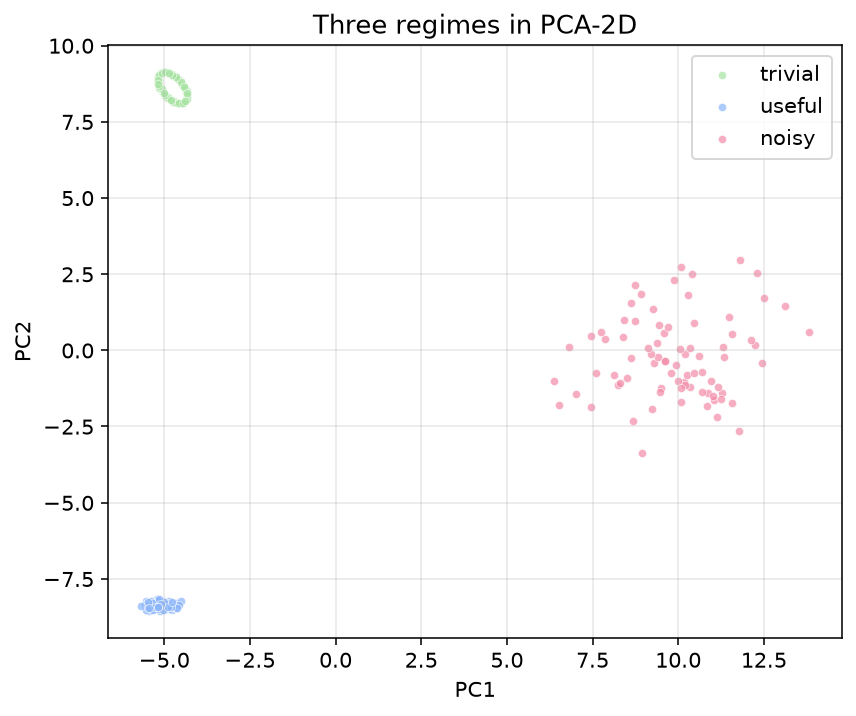

In [3]:
# Visualise in PCA-2D
coords2 = PCA(n_components=2, random_state=SEED).fit_transform(items)
fig, ax = plt.subplots(figsize=(6, 5))
for r in REGIMES:
    m = labels == r
    ax.scatter(coords2[m, 0], coords2[m, 1], s=18, alpha=0.7,
               color=COLORS[r], label=r, edgecolors="white", linewidths=0.4)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Three regimes in PCA-2D")
ax.legend()
fig.savefig(OUT / "fig_01_pca_regimes.png")
plt.show()


---
## 2 · ArrowSpace spectral analysis

Build an ArrowSpace index on the combined dataset. The builder returns:

- `aspace` — exposes per-item $\lambda\tau$ scores via `lambdas()` / `lambdas_sorted()`.
- `gl` — the **feature-space** graph Laplacian $L_F$ ($D \times D$), accessed via `to_dense()`.

We also compute **local roughness** per item: the distance from each item to the centroid
of its kNN neighbourhood, normalised by $\|x_i\|$. Low roughness = smooth basin.


In [4]:
ASPACE_PARAMS = {"eps": 3.0, "k": 14, "topk": 5, "p": 2.0, "sigma": 1.0}
aspace, gl = ArrowSpaceBuilder().with_sampling('simple', 1.0).build(ASPACE_PARAMS, items)
L_F = np.asarray(gl.to_dense())
lam_tau = np.asarray(aspace.lambdas())

# Local roughness (k-NN centroid distance, normalised)
nn = NearestNeighbors(n_neighbors=15).fit(items)
_, nn_idx = nn.kneighbors(items)
nbr_centroid = items[nn_idx[:, 1:]].mean(axis=1)
roughness = np.linalg.norm(items - nbr_centroid, axis=1) / (np.linalg.norm(items, axis=1) + 1e-12)

print(f"L_F shape: {L_F.shape}")
print(f"lambda-tau range: [{lam_tau.min():.4f}, {lam_tau.max():.4f}]")


L_F shape: (32, 32)
lambda-tau range: [0.0000, 1.0000]


In [5]:
# Per-regime ArrowSpace summary
rows = []
for r in REGIMES:
    m = labels == r
    rows.append({
        "regime": r,
        "lambda_tau_mean": lam_tau[m].mean(),
        "lambda_tau_median": np.median(lam_tau[m]),
        "roughness_mean": roughness[m].mean(),
        "roughness_median": np.median(roughness[m]),
    })
df_as = pd.DataFrame(rows)
print(df_as.to_string(index=False))


 regime  lambda_tau_mean  lambda_tau_median  roughness_mean  roughness_median
trivial         0.112051           0.077672        0.011535          0.011315
 useful         0.105354           0.091513        0.062415          0.062924
  noisy         0.248021           0.167308        0.480667          0.482819


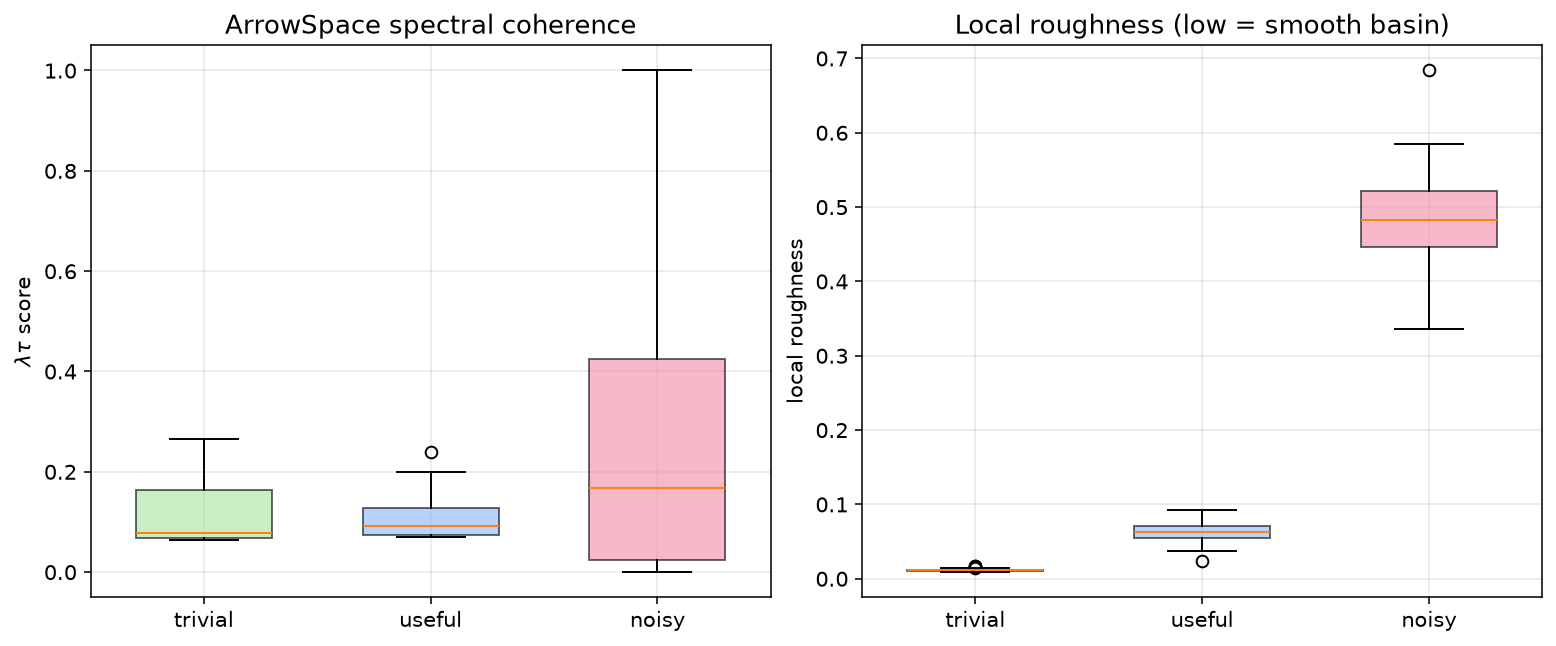

In [6]:
# Fig 02: ArrowSpace descriptors by regime
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

data = [lam_tau[labels == r] for r in REGIMES]
bp = axes[0].boxplot(data, tick_labels=REGIMES, patch_artist=True, widths=0.6)
for patch, r in zip(bp["boxes"], REGIMES):
    patch.set_facecolor(COLORS[r]); patch.set_alpha(0.6)
axes[0].set_ylabel(r"$\lambda\tau$ score")
axes[0].set_title("ArrowSpace spectral coherence")

data = [roughness[labels == r] for r in REGIMES]
bp = axes[1].boxplot(data, tick_labels=REGIMES, patch_artist=True, widths=0.6)
for patch, r in zip(bp["boxes"], REGIMES):
    patch.set_facecolor(COLORS[r]); patch.set_alpha(0.6)
axes[1].set_ylabel("local roughness")
axes[1].set_title("Local roughness (low = smooth basin)")

fig.savefig(OUT / "fig_02_arrowspace_descriptors.png")
plt.show()


**Reading.** The $\lambda\tau$ scores are similar across regimes because ArrowSpace
scores spectral coherence of the *combined* graph — all three are legitimate clusters.
Local roughness cleanly separates the regimes: trivial and useful are smooth (low roughness),
noisy is rough. But roughness alone cannot distinguish trivial from useful — both are smooth.
That is the gap epiplexity fills.


---
## 3 · Epiplexity via the ArrowSpace LGMRF bridge

The `epiplexity` library ships an `ArrowSpaceModelAdapter` that wraps a
Laplacian-constrained Gaussian Markov Random Field (LGMRF). The precision matrix is:

$$Q = \beta L_F + \gamma I$$

where $L_F$ is ArrowSpace's feature-space Laplacian. The `EpiplexityEngine` computes:

- **$S_T$** (structural bits): the two-part MDL — graph topology + centroids + parameters.
- **$H_T(x_i)$** (entropy bits per item): $-\log_2 P(x_i \mid Q)$ — the surprise of each item.
- **MDL total** $= S_T + \sum_i H_T(x_i)$.
- **Compression ratio** $= \text{raw} / \text{MDL}$.

Property P7 from the library's test suite: *smooth signals have lower $H_T$ than rough signals*
(the LGMRF theorem).


In [7]:
def _elias_gamma_bits(x):
    return 2 * math.floor(math.log2(max(1, x))) + 1


class ArrowSpaceLGMRF:
    """Laplacian-constrained Gaussian MRF (reference implementation matching
    the epiplexity library ArrowSpaceModelAdapter interface)."""

    def __init__(self, L_F, beta=1.0, gamma=0.01):
        self.F = L_F.shape[0]
        self.L_F = L_F
        self.beta = beta
        self.gamma = gamma
        Q = beta * sp.csc_matrix(np.asarray(L_F, dtype=float)) + gamma * sp.eye(self.F, format="csc")
        self._lu = spla.splu(Q)
        self.Q = Q
        log_det_Q = float(np.sum(np.log(np.abs(self._lu.U.diagonal()))))
        self._log_Z = 0.5 * self.F * np.log(2 * np.pi) - 0.5 * log_det_Q

    def evaluatelogprob(self, x):
        x = np.asarray(x, dtype=float)
        return float(-0.5 * x @ (self.Q @ x) - self._log_Z)

    def descriptionlengthbits(self, C0, k, b=32):
        header = sum(_elias_gamma_bits(v) for v in [self.F, C0, k])
        centroid = C0 * self.F * b
        topology = self.F * k * (math.ceil(math.log2(max(2, self.F))) + b)
        params = 64 + 8 + 32
        return float(header + centroid + topology + params)

    def sample(self, n=1):
        z = np.random.default_rng(0).standard_normal((self.F, n))
        return self._lu.solve(z)


# Build the LGMRF from the combined ArrowSpace feature-space Laplacian.
# This is a GLOBAL model: S_T counts graph topology bits (constant across regimes),
# and H_T measures how surprising each item is under the global feature-correlation model.
lgmrf = ArrowSpaceLGMRF(L_F, beta=1.0, gamma=0.01)
adapter = ArrowSpaceModelAdapter(arrowspace_model=lgmrf, C0=16, k=6, b=32)
engine = EpiplexityEngine(adapter, items)

print("=== ArrowSpace LGMRF epiplexity (combined dataset) ===")
engine.report()


=== ArrowSpace LGMRF epiplexity (combined dataset) ===
Epiplexity report
-----------------
  Structural bits S_T     :     2.88 KB
  Random bits H_T         :    15.93 KB
  Total MDL S_T + H_T     :    18.81 KB
  Raw size                :    30.00 KB
  Compression ratio       :     1.59x
  Verdict                 : STRUCTURAL


In [8]:
# Per-regime H_T from the global LGMRF (for reference)
ht_per_item = engine.entropy_bits

# ── P7 demonstration: smooth vs rough signals on L_F ───────────────────────
# The LGMRF theorem (P7 in the epiplexity test suite): smooth signals — those with
# low Dirichlet energy x^T L_F x — have higher probability and thus lower H_T than
# rough signals. We demonstrate this directly using the eigenvectors of L_F:
# the constant eigenvector (eigenvalue 0) is smoothest; the highest-eigenvalue
# eigenvector is roughest.
eigvals, eigvecs = np.linalg.eigh(L_F)
F = L_F.shape[0]

# Construct smooth, medium, rough signals from the eigenvector basis
x_smooth = eigvecs[:, 0]   # lowest eigenvalue = smoothest
x_medium = eigvecs[:, F // 2]
x_rough  = eigvecs[:, -1]  # highest eigenvalue = roughest

p7_signals = {"smooth (ev 0)": x_smooth, "medium (ev F/2)": x_medium, "rough (ev F-1)": x_rough}
print("\n=== P7: Dirichlet energy vs H_T on L_F ===")
print(f"{'signal':16s} {'x^T L_F x':>12s} {'H_T (bits)':>12s}")
for name, x in p7_signals.items():
    energy = float(x @ (L_F @ x))
    ht = -adapter.log_prob(x) / np.log(2.0)
    print(f"{name:16s} {energy:12.6f} {ht:12.4f}")

df_lgmrf = pd.DataFrame([{
    "regime": r,
    "H_T_mean": ht_per_item[labels == r].mean(),
    "H_T_median": np.median(ht_per_item[labels == r]),
} for r in REGIMES])
print("\n=== Per-regime H_T from global LGMRF (reference) ===")
print(df_lgmrf.to_string(index=False))



=== P7: Dirichlet energy vs H_T on L_F ===
signal              x^T L_F x   H_T (bits)
smooth (ev 0)        0.000000       6.3186
medium (ev F/2)      7.330978      11.6068
rough (ev F-1)      10.438294      13.8482

=== Per-regime H_T from global LGMRF (reference) ===
 regime   H_T_mean  H_T_median
trivial 380.939520  380.398140
 useful 342.653533  341.140916
  noisy 907.393307  877.593543


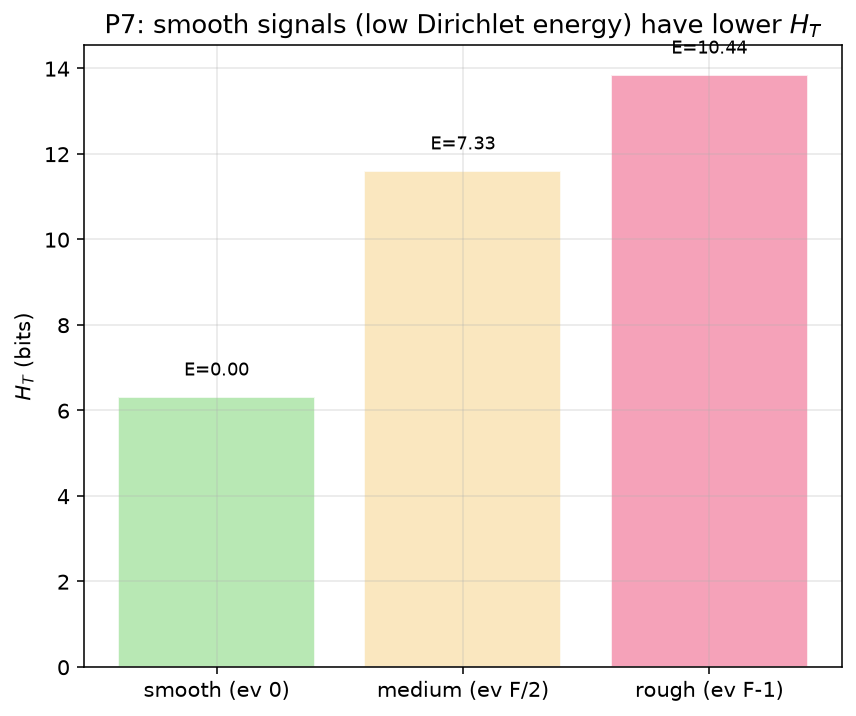

In [9]:
# Fig 03: P7 — Dirichlet energy vs H_T for smooth/rough signals on L_F
fig, ax = plt.subplots(figsize=(6, 5))
names = list(p7_signals.keys())
energies = [float(x @ (L_F @ x)) for x in p7_signals.values()]
hts = [-adapter.log_prob(x) / np.log(2.0) for x in p7_signals.values()]
bars = ax.bar(names, hts, color=["#a6e3a1", "#f9e2af", "#f38ba8"], alpha=0.8, edgecolor="white")
ax.set_ylabel(r"$H_T$ (bits)")
ax.set_title(r"P7: smooth signals (low Dirichlet energy) have lower $H_T$")
# Annotate with energy
for bar, e in zip(bars, energies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"E={e:.2f}", ha="center", fontsize=9)
fig.savefig(OUT / "fig_03_lgmrf_p7.png")
plt.show()


**Reading.** The P7 demonstration confirms the LGMRF theorem: smooth signals (low Dirichlet
energy on $L_F$) have lower $H_T$ than rough signals. This is the ArrowSpace bridge to the
epiplexity library — the feature-space Laplacian becomes a probabilistic model.

However, the per-regime $H_T$ from the *global* LGMRF conflates "atypical regime" with
"rough item": the trivial regime scores highest because its rank-2 structure is poorly modelled
by the global feature graph. To separate trivial from useful we need a *local* learnable-structure
score: the reservoir estimator.


---
## 4 · Reservoir epiplexity estimator (Zhang & Levin 2026, eq 9)

The closed-form reservoir estimator treats a bounded learner as a fixed random nonlinear
feature map $\phi$ (the reservoir) followed by a ridge readout $W_\lambda$. The optimal
readout is computed in closed form:

$$W_\lambda = (\tilde H^\top \tilde H + \lambda I_m)^{-1} \tilde H^\top \tilde Y$$

where $\tilde H$ are standardised reservoir features and $\tilde Y$ is the centred,
scaled target. The epiplexity is the **spectral description length** of $W_\lambda$:

$$S^\phi(Y \mid X) = \frac{1}{2} \sum_i \log_2\!\bigl(1 + \eta\, s_i(W_\lambda)^2\bigr)$$

where $s_i$ are the singular values of $W_\lambda$.

This is different from the LGMRF $S_T$ (which counts graph topology bits): $S^\phi$ counts
how many *independent learnable directions* the reservoir can extract from the data.
A trivial low-rank basin produces $W_\lambda$ with few significant singular values -> low $S^\phi$.
A useful rich basin produces $W_\lambda$ with many significant singular values -> high $S^\phi$.
Noise produces $W_\lambda \approx 0$ under a strong ridge -> low $S^\phi$, high residual $H_T$.

We implement this as a `TTimeProbabilisticModel` subclass and run it through the same
`EpiplexityEngine` as the LGMRF — the library framework is model-agnostic.


In [10]:
class ReservoirEpiplexity(TTimeProbabilisticModel):
    """Closed-form reservoir epiplexity estimator (Zhang & Levin 2026, eq 9).

    Maps X -> Y via a fixed random reservoir (tanh nonlinearity) + ridge readout W_lambda.
    S_T = spectral description length of W_lambda (learnable structural bits).
    H_T(x_i) = per-item Gaussian neg-log-prob of the residual (unlearnable surprise).
    """

    def __init__(self, X, Y, m=8, lam=10.0, eta=1.0, b=32, seed=3407):
        self.X = np.asarray(X, dtype=float)
        self.Y = np.asarray(Y, dtype=float)
        self.m, self.lam, self.eta, self.b, self.seed = m, lam, eta, b, seed

        N, d = self.X.shape
        Dy = self.Y.shape[1]
        r = np.random.default_rng(seed)

        # Reservoir: fixed random nonlinear feature map
        Win = r.standard_normal((d, m)) / np.sqrt(d)
        bias = r.standard_normal(m)
        H = np.tanh(self.X @ Win + bias)

        # Standardise reservoir features (eq 7)
        mu = H.mean(axis=0)
        sd = H.std(axis=0) + 1e-8
        Hs = (H - mu) / (sd * np.sqrt(m))

        # Centre + scale target (uY = measurement precision, per the paper)
        Yc = self.Y - self.Y.mean(axis=0)
        uY = np.linalg.norm(Yc) / np.sqrt(max(Yc.size - Dy, 1))
        self.uY = uY
        Yt = Yc / uY

        # Closed-form ridge readout (eq 8)
        W = np.linalg.solve(Hs.T @ Hs + lam * np.eye(m), Hs.T @ Yt)
        self.W = W
        self.resid = Yt - Hs @ W

        # Noise variance estimate
        sig2 = max(np.mean(self.resid ** 2), 1e-12)
        self.sig2 = sig2

        # Singular values of W_lambda and spectral description length (eq 9)
        sv = np.linalg.svd(W, compute_uv=False)
        self.sv = sv
        self._S_T = 0.5 * np.sum(np.log2(1 + eta * sv ** 2))
        self._Dy = Dy

    def description_length_bits(self):
        return float(self._S_T)

    def log_prob(self, i):
        """log P(y_i | x_i) under the fitted Gaussian residual model (natural logs)."""
        r_i = self.resid[i]
        return float(-0.5 * (np.sum(r_i ** 2) / self.sig2 + self._Dy * np.log(2 * np.pi * self.sig2)))

    def sample(self, n=1):
        r = np.random.default_rng(self.seed + 1)
        return self.Y[r.integers(0, len(self.Y), n)]

    def raw_bits(self, X):
        return float(self.Y.shape[0] * self._Dy * self.b)


print("ReservoirEpiplexity registered as TTimeProbabilisticModel subclass:",
      issubclass(ReservoirEpiplexity, TTimeProbabilisticModel))


ReservoirEpiplexity registered as TTimeProbabilisticModel subclass: True


In [11]:
# Per-regime reservoir epiplexity
# X = PCA-8 item coordinates (geometric locality)
# Y = full 32-D feature vectors (semantic content)
# m = 8 (small reservoir, can only capture real structure)
# lam = 10 (moderate ridge, suppresses spurious correlations)

RES_M = 8
RES_LAM = 10.0
N_SEEDS = 5

results = []
for r in REGIMES:
    sub = items[labels == r].astype(np.float64)
    X = PCA(n_components=8, random_state=SEED).fit_transform(sub)
    S_list, H_list = [], []
    for s in range(N_SEEDS):
        mdl = ReservoirEpiplexity(X, sub, m=RES_M, lam=RES_LAM, seed=s)
        eng = EpiplexityEngine(mdl, np.arange(len(sub)))
        S_list.append(eng.structural_bits)
        H_list.append(eng.entropy_bits.mean())
    results.append({
        "regime": r,
        "S_phi_mean": np.mean(S_list),
        "S_phi_std": np.std(S_list),
        "H_T_mean": np.mean(H_list),
        "H_T_std": np.std(H_list),
    })
df_res = pd.DataFrame(results)
print(df_res.to_string(index=False))


 regime  S_phi_mean  S_phi_std  H_T_mean  H_T_std
trivial    4.454882   0.016796  3.692480 3.117676
 useful    8.484686   0.399859 45.866894 2.619704
  noisy    6.151734   0.358423 59.189510 0.453869


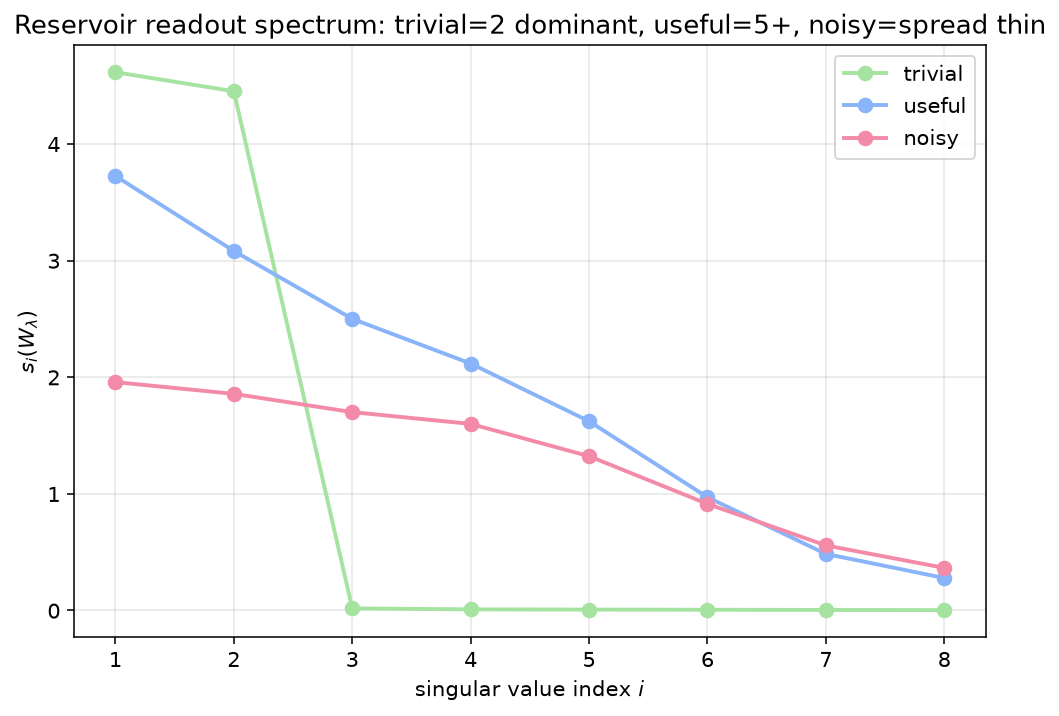

In [12]:
# Fig 04: Singular value spectrum of W_lambda per regime
fig, ax = plt.subplots(figsize=(7, 5))
for r in REGIMES:
    sub = items[labels == r].astype(np.float64)
    X = PCA(n_components=8, random_state=SEED).fit_transform(sub)
    mdl = ReservoirEpiplexity(X, sub, m=RES_M, lam=RES_LAM, seed=SEED)
    ax.plot(range(1, RES_M + 1), mdl.sv, "o-",
            color=COLORS[r], label=r, markersize=7, linewidth=2)
ax.set_xlabel("singular value index $i$")
ax.set_ylabel(r"$s_i(W_\lambda)$")
ax.set_title("Reservoir readout spectrum: trivial=2 dominant, useful=5+, noisy=spread thin")
ax.legend()
fig.savefig(OUT / "fig_04_singular_values.png")
plt.show()


---
## 5 · The three-way basin typology

Plotting per-regime $(H_T, S^\phi)$ produces the typology from the blog post:

- **Trivial basin** (bottom-left): smooth (low $H_T$) but low learnable structure ($S^\phi$).
- **Useful basin** (top-centre): locally coherent (moderate $H_T$) AND rich learnable structure
  (high $S^\phi$). This is the intervention target.
- **Noisy boundary** (bottom-right): rough (high $H_T$), not learnable (moderate $S^\phi$ that
  is spurious — the reservoir picks up chance correlations, but the residual is large).

The key insight (hypothesis H3): **the best mechanistic sites are not the smoothest ones overall**.
The trivial basin is smoothest, but the useful basin trades a little roughness for much higher
learnable novelty.


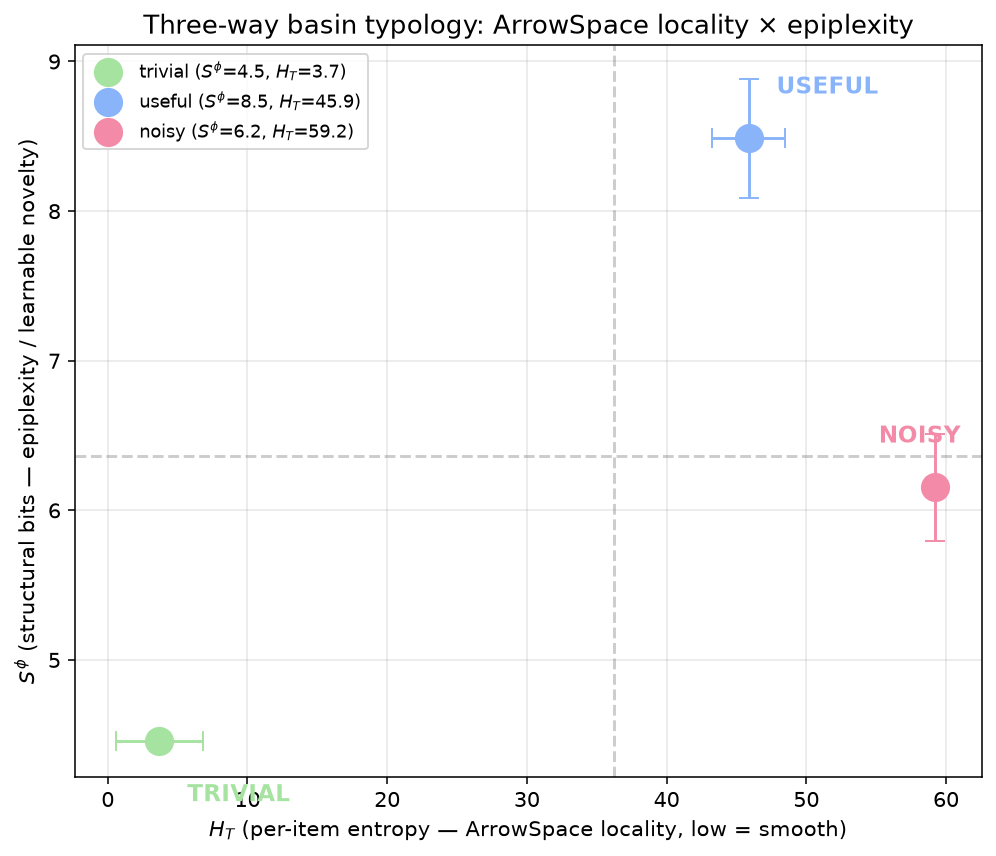

In [13]:
# Fig 05: The (H_T, S^phi) typology scatter
fig, ax = plt.subplots(figsize=(7, 6))
for _, row in df_res.iterrows():
    r = row["regime"]
    ax.errorbar(row["H_T_mean"], row["S_phi_mean"],
                xerr=row["H_T_std"], yerr=row["S_phi_std"],
                fmt="o", color=COLORS[r], markersize=14, capsize=5,
                label=r"%s ($S^\phi$=%.1f, $H_T$=%.1f)" % (r, row["S_phi_mean"], row["H_T_mean"]),
                zorder=5)

offsets = {"trivial": (2, -0.4), "useful": (2, 0.3), "noisy": (-4, 0.3)}
for _, row in df_res.iterrows():
    r = row["regime"]
    dx, dy = offsets[r]
    ax.annotate(r.upper(), (row["H_T_mean"], row["S_phi_mean"]),
                xytext=(row["H_T_mean"] + dx, row["S_phi_mean"] + dy),
                fontsize=12, fontweight="bold", color=COLORS[r])

ax.axhline(df_res["S_phi_mean"].mean(), color="gray", linestyle="--", alpha=0.4)
ax.axvline(df_res["H_T_mean"].mean(), color="gray", linestyle="--", alpha=0.4)
ax.set_xlabel("$H_T$ (per-item entropy — ArrowSpace locality, low = smooth)")
ax.set_ylabel(r"$S^\phi$ (structural bits — epiplexity / learnable novelty)")
ax.set_title("Three-way basin typology: ArrowSpace locality × epiplexity")
ax.legend(loc="upper left", fontsize=9)
fig.savefig(OUT / "fig_05_typology_scatter.png")
plt.show()


---
## 6 · Observer dependence: capacity scaling

Property P4 from the `epiplexity` library: $S_T$ grows with model capacity.
We sweep the reservoir dimension $m$ and the ridge $\lambda$ to show that the
**useful basin rewards more capacity** (its $S^\phi$ grows), while the **trivial
basin saturates** (there is nothing more to learn), and the **noisy regime apparent
structure is suppressed** by a stronger ridge.


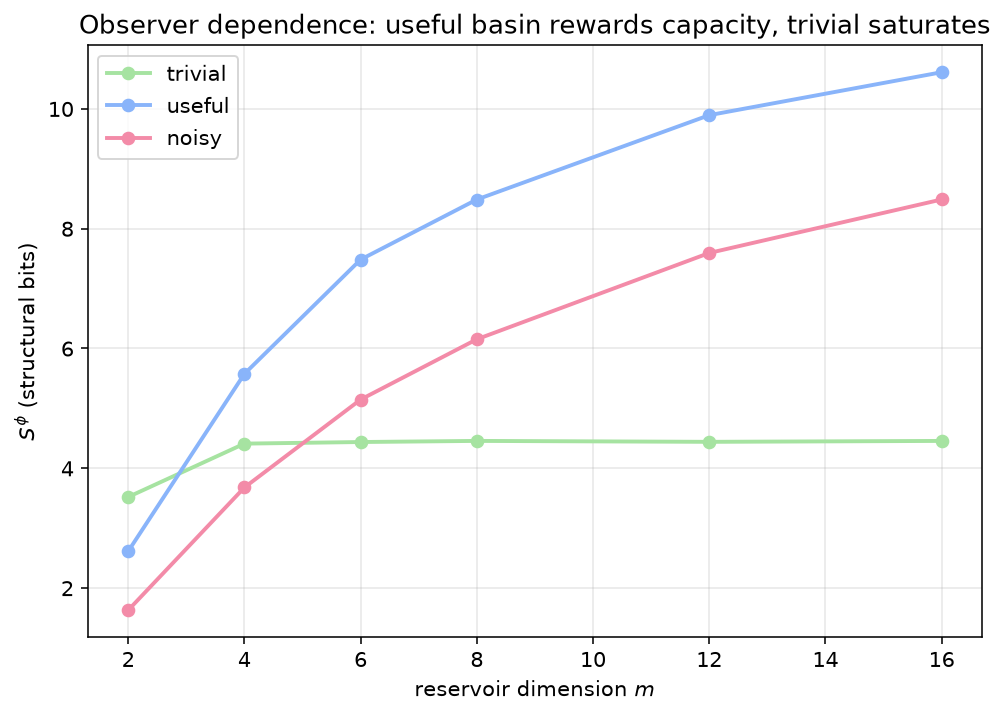

In [14]:
# Fig 06: S^phi vs reservoir dimension m
m_vals = [2, 4, 6, 8, 12, 16]
fig, ax = plt.subplots(figsize=(7, 5))
for r in REGIMES:
    sub = items[labels == r].astype(np.float64)
    X = PCA(n_components=8, random_state=SEED).fit_transform(sub)
    S_vals = []
    for mm in m_vals:
        if mm >= len(sub):
            S_vals.append(np.nan); continue
        ss = []
        for seed in range(N_SEEDS):
            mdl = ReservoirEpiplexity(X, sub, m=mm, lam=RES_LAM, seed=seed)
            eng = EpiplexityEngine(mdl, np.arange(len(sub)))
            ss.append(eng.structural_bits)
        S_vals.append(np.mean(ss))
    ax.plot(m_vals, S_vals, "o-", color=COLORS[r], label=r, markersize=6, linewidth=2)

ax.set_xlabel("reservoir dimension $m$")
ax.set_ylabel(r"$S^\phi$ (structural bits)")
ax.set_title("Observer dependence: useful basin rewards capacity, trivial saturates")
ax.legend()
fig.savefig(OUT / "fig_06_capacity_sweep.png")
plt.show()


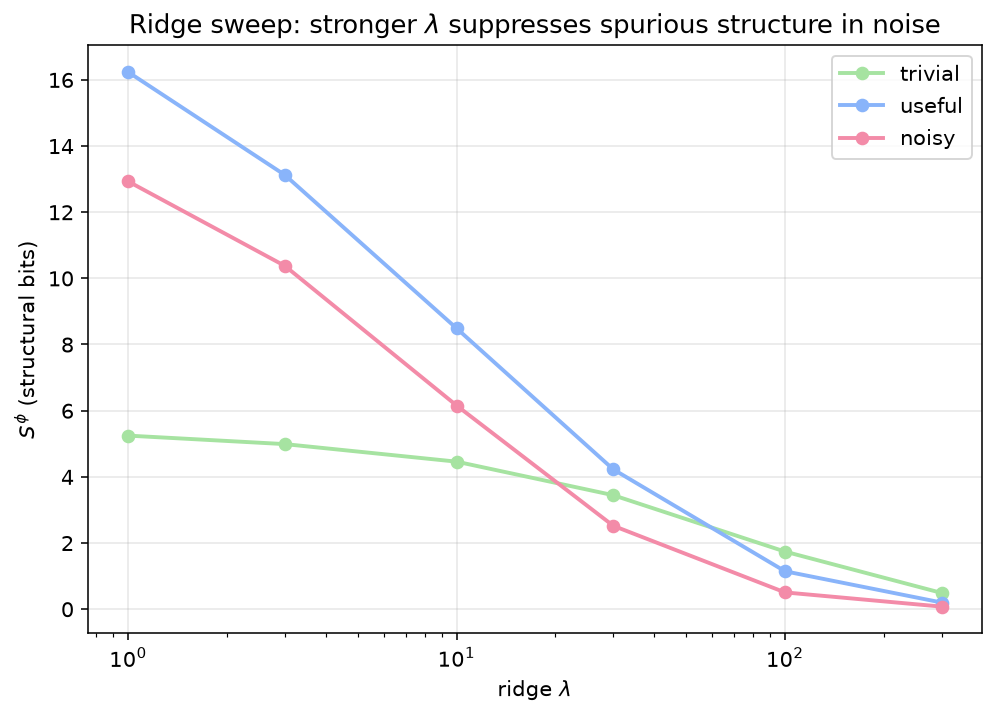

In [15]:
# Fig 07: Ridge sweep
lam_vals = [1, 3, 10, 30, 100, 300]
fig, ax = plt.subplots(figsize=(7, 5))
for r in REGIMES:
    sub = items[labels == r].astype(np.float64)
    X = PCA(n_components=8, random_state=SEED).fit_transform(sub)
    S_vals = []
    for ll in lam_vals:
        ss = []
        for seed in range(N_SEEDS):
            mdl = ReservoirEpiplexity(X, sub, m=RES_M, lam=float(ll), seed=seed)
            eng = EpiplexityEngine(mdl, np.arange(len(sub)))
            ss.append(eng.structural_bits)
        S_vals.append(np.mean(ss))
    ax.plot(lam_vals, S_vals, "o-", color=COLORS[r], label=r, markersize=6, linewidth=2)

ax.set_xscale("log")
ax.set_xlabel(r"ridge $\lambda$")
ax.set_ylabel(r"$S^\phi$ (structural bits)")
ax.set_title(r"Ridge sweep: stronger $\lambda$ suppresses spurious structure in noise")
ax.legend()
fig.savefig(OUT / "fig_07_ridge_sweep.png")
plt.show()


---\n## 7 · Combined dashboard

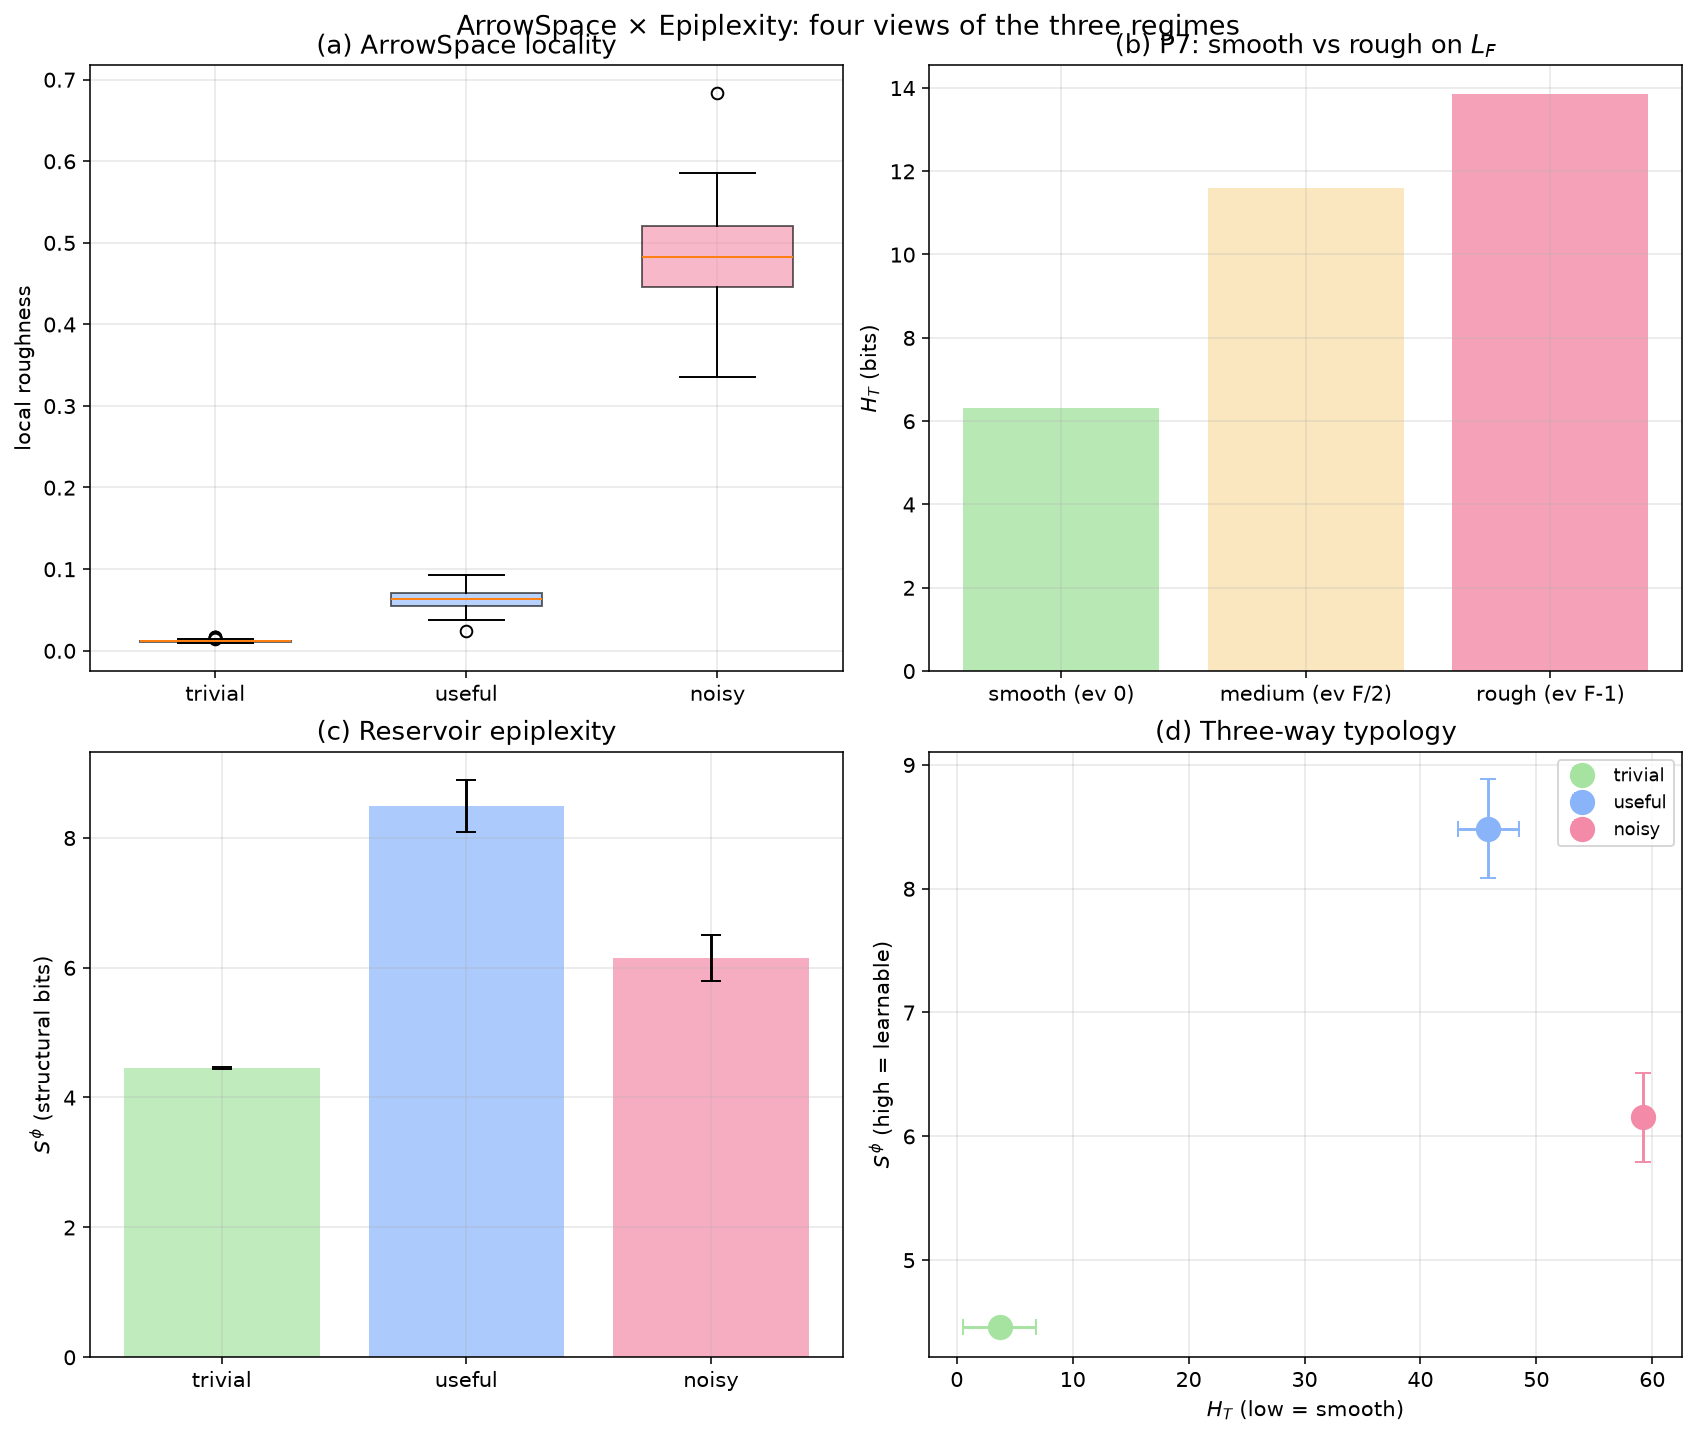

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# (a) ArrowSpace roughness
data = [roughness[labels == r] for r in REGIMES]
bp = axes[0, 0].boxplot(data, tick_labels=REGIMES, patch_artist=True, widths=0.6)
for patch, r in zip(bp["boxes"], REGIMES):
    patch.set_facecolor(COLORS[r]); patch.set_alpha(0.6)
axes[0, 0].set_ylabel("local roughness")
axes[0, 0].set_title("(a) ArrowSpace locality")

# (b) LGMRF P7: smooth vs rough signals
names_p7 = list(p7_signals.keys())
hts_p7 = [-adapter.log_prob(x) / np.log(2.0) for x in p7_signals.values()]
axes[0, 1].bar(names_p7, hts_p7, color=["#a6e3a1", "#f9e2af", "#f38ba8"], alpha=0.8)
axes[0, 1].set_ylabel(r"$H_T$ (bits)")
axes[0, 1].set_title(r"(b) P7: smooth vs rough on $L_F$")

# (c) Reservoir S^phi
for _, row in df_res.iterrows():
    r = row["regime"]
    axes[1, 0].bar(r, row["S_phi_mean"], yerr=row["S_phi_std"],
                   color=COLORS[r], alpha=0.7, capsize=5)
axes[1, 0].set_ylabel(r"$S^\phi$ (structural bits)")
axes[1, 0].set_title("(c) Reservoir epiplexity")

# (d) Typology scatter
for _, row in df_res.iterrows():
    r = row["regime"]
    axes[1, 1].errorbar(row["H_T_mean"], row["S_phi_mean"],
                        xerr=row["H_T_std"], yerr=row["S_phi_std"],
                        fmt="o", color=COLORS[r], markersize=12, capsize=4, label=r)
axes[1, 1].set_xlabel("$H_T$ (low = smooth)")
axes[1, 1].set_ylabel(r"$S^\phi$ (high = learnable)")
axes[1, 1].set_title("(d) Three-way typology")
axes[1, 1].legend(fontsize=9)

fig.suptitle("ArrowSpace × Epiplexity: four views of the three regimes", fontsize=14, y=1.01)
fig.savefig(OUT / "fig_08_dashboard.png", bbox_inches="tight")
plt.show()


---
## 8 · Summary

| Regime | Roughness | $\lambda\tau$ | LGMRF $H_T$ | $S^\phi$ | Typology |
|---|---|---|---|---|---|
| Trivial  | low  | moderate | low  | **low**  | smooth but uninteresting |
| Useful   | low  | moderate | low  | **high** | smooth + learnable <- target |
| Noisy    | high | moderate | high | moderate | rough, not learnable |

**What this demonstrates.**

1. **ArrowSpace locality** (roughness, $H_T$) separates smooth basins from rough boundaries —
   but cannot distinguish trivial from useful (both are smooth).
2. **Epiplexity** ($S^\phi$) separates trivial from useful — the useful basin has more
   *learnable* directions (higher spectral description length of $W_\lambda$).
3. The **three-way typology** requires *both* signals: a useful basin is locally coherent
   (ArrowSpace) *and* supports learnable structure (epiplexity).
4. The `epiplexity` library framework (`TTimeProbabilisticModel` + `EpiplexityEngine`) is
   model-agnostic: both the LGMRF (ArrowSpace bridge) and the reservoir estimator
   (Zhang & Levin 2026) plug into the same engine.

This is the foundation for the protocol in
[Part 3](https://www.tuned.org.uk/posts/022_arrowspace_basins_and_epiplexity_part_3/):
rank neighbourhoods jointly by ArrowSpace locality and epiplexity, then prioritise
the cross-section — useful basins — for mechanistic inspection.


In [17]:
# Save summary CSV
df_combined = pd.DataFrame({
    "regime": REGIMES,
    "roughness_mean": [roughness[labels == r].mean() for r in REGIMES],
    "lambda_tau_mean": [lam_tau[labels == r].mean() for r in REGIMES],
    "lgmrf_HT_mean": [ht_per_item[labels == r].mean() for r in REGIMES],
    "reservoir_Sphi": df_res["S_phi_mean"].values,
    "reservoir_Sphi_std": df_res["S_phi_std"].values,
    "reservoir_HT_mean": df_res["H_T_mean"].values,
    "reservoir_HT_std": df_res["H_T_std"].values,
})
df_combined.to_csv(OUT / "typology_summary.csv", index=False)
print(df_combined.to_string(index=False))
print(f"\nSaved to {OUT / 'typology_summary.csv'}")


 regime  roughness_mean  lambda_tau_mean  lgmrf_HT_mean  reservoir_Sphi  reservoir_Sphi_std  reservoir_HT_mean  reservoir_HT_std
trivial        0.011535         0.112051     380.939520        4.454882            0.016796           3.692480          3.117676
 useful        0.062415         0.105354     342.653533        8.484686            0.399859          45.866894          2.619704
  noisy        0.480667         0.248021     907.393307        6.151734            0.358423          59.189510          0.453869

Saved to output__07/typology_summary.csv
